# BikeFlow 05 — Tree Models / 模型选择

**问题：**在 04 的 V2-D 数据、时间切分和 45 个特征完全相同的条件下，换用 sklearn 的非线性回归模型，能否降低逐小时骑行需求预测误差？

本 Notebook 只比较 **Linear Regression、Random Forest、HistGradientBoosting**。主指标是同一测试集上的原始预测 MAE；同时检查 RMSE、R²、负预测、通勤高峰与训练／测试差距。数据源是 `data/processed/bikeflow_2024.csv`，复现依据是 `notebooks/04_lag_features.ipynb` 的 V2-D。

**预测口径：**逐小时滚动预测。预测某小时之前，前面已发生小时的真实骑行量可用于 lag。天气字段沿用 04 的历史观测数据；这是回顾性比较，实际提前预测须使用当时可获得的天气预报。

**本次运行速览：**HistGradientBoosting 的测试 MAE 为 391.42，相对 V2-D Linear Regression 的 745.08 降低 47.47%；全部原始指标、局部诊断和限制见下文。

## 1. 实验边界与模型直觉

- **Decision Tree（决策树）**不断按特征阈值分组，例如“是否 08:00？”、“上一小时骑行量是否超过某值？”，再给不同组不同预测。因此它能学习线性加法模型难以表达的条件关系和交互。
- **Random Forest（随机森林）**训练许多带随机性的决策树，再平均预测。平均可减小单棵树的波动，但森林仍可能记住训练期细节。
- **Gradient Boosting（梯度提升）**依次训练较小的树，每棵树重点修正前面模型的残差。这里使用 sklearn 的 `HistGradientBoostingRegressor`，它用分箱加速阈值搜索。
- 树按数值大小选择切分阈值；对数值做 `StandardScaler` 通常不改变其排序，所以树模型一般不需要它。本实验也不给线性模型加缩放，以便精确复现 04。

**公平性约束：**固定同一训练行、同一测试行、同一列顺序；不新增 lag、rolling 或其他特征；不在测试集上调参；不把当前或未来目标值作为当前特征。

### 1.1 导入工具

**做什么：**导入表格、绘图和三个 sklearn 模型。**为什么：**后面的数据构造、训练和指标都需要这些工具。**输入：**当前 Python 环境。**输出：**可复用的函数与统一图表样式。

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "font.size": 10,
    "axes.grid": False,
    "savefig.dpi": 130,
})
MODEL_COLORS = {
    "Linear Regression": "#C66A32",
    "Random Forest": "#24567A",
    "HistGradientBoosting": "#69803C",
}

## 2. 读取与 04 相同的数据

**做什么：**读取处理后的 2024 年逐小时数据，并检查时间索引。**为什么：**不同模型必须从同一份数据出发。**输入：**`data/processed/bikeflow_2024.csv`。**输出：**按本地钟表时间排序的原始小时表；它包含夏令时特殊标签，稍后只从建模行中排除。

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("请从 BikeFlow 项目根目录或 notebooks 目录运行")

data = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
data = data.sort_values("timestamp").reset_index(drop=True)
assert len(data) == 8784
assert not data["timestamp"].duplicated().any()
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()
print(f"数据文件：{DATA_PATH}")
print(f"原始维度：{data.shape}；时间范围：{data['timestamp'].min()} 至 {data['timestamp'].max()}")
display(data.head(3))

数据文件：C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
原始维度：(8784, 10)；时间范围：2024-01-01 00:00:00 至 2024-12-31 23:00:00


,timestamp,ride_count,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2024-01-01 00:00:00,1901,1.8,-2.1,71.0,0.0,0.0,0.0,3.0,9.0
1,2024-01-01 01:00:00,2333,2.4,-1.7,71.0,0.0,0.0,0.0,3.0,10.9
2,2024-01-01 02:00:00,1939,2.4,-1.5,73.0,0.0,0.0,0.0,3.0,10.1


### 2.1 固定建模行与时间边界

**做什么：**像 04 一样排除春季不存在的 02:00 和秋季合并的 01:00 建模行，然后在删除 lag 缺失值之前确定 80/20 时间边界。**为什么：**如果先删除 lag 空值再重新按比例切分，测试时段会移动，模型比较就不公平。**输入：**完整小时表。**输出：**8,782 个 V1 建模行与固定的测试起点。

In [3]:
SPRING_GAP = pd.Timestamp("2024-03-10 02:00")
FALL_REPEAT = pd.Timestamp("2024-11-03 01:00")
spring_row = data.loc[data["timestamp"].eq(SPRING_GAP)]
fall_row = data.loc[data["timestamp"].eq(FALL_REPEAT)]
assert len(spring_row) == len(fall_row) == 1
assert spring_row["ride_count"].iloc[0] == 0
assert spring_row.drop(columns=["timestamp", "ride_count"]).isna().all(axis=None)

normal_hour_mask = ~data["timestamp"].isin([SPRING_GAP, FALL_REPEAT])
model_data = data.loc[normal_hour_mask].copy().reset_index(drop=True)
model_data["hour"] = model_data["timestamp"].dt.hour
model_data["day_of_week"] = model_data["timestamp"].dt.dayofweek
model_data["month"] = model_data["timestamp"].dt.month

split_index = int(len(model_data) * 0.8)
fixed_test_start = model_data["timestamp"].iloc[split_index]
assert len(model_data) == 8782 and split_index == 7025
assert fixed_test_start == pd.Timestamp("2024-10-19 18:00")
print(f"建模行：{len(model_data):,}；原始 V1 切分位置：{split_index:,}")
print(f"固定测试起点：{fixed_test_start}")

建模行：8,782；原始 V1 切分位置：7,025
固定测试起点：2024-10-19 18:00:00


### 2.2 复现三个历史需求 lag

**做什么：**先在完整的连续钟表小时序列上对 `ride_count` 做 `shift(1/24/168)`，再映射到建模行。**为什么：**这与 04 的 V2-D 完全一致，也避免先删夏令时行导致附近 lag 错位。**输入：**按时间排序的原始 `ride_count`。**输出：**只引用当前小时以前真实需求的三列 lag。

测试期的 lag 可以引用此前**已经发生**的测试小时，因此本实验评估逐小时滚动预测；它不代表在 10 月一次性预报到 12 月。春季占位行与秋季合并行仍可能被随后时刻的 lag 引用，这是沿用 04 的数据口径。

In [4]:
lag_columns = ["lag_1", "lag_24", "lag_168"]
for hours_back in (1, 24, 168):
    lag_name = f"lag_{hours_back}"
    data[lag_name] = data["ride_count"].shift(hours_back)
    source_time = data["timestamp"].shift(hours_back)
    valid = data[lag_name].notna()
    assert (source_time.loc[valid] < data.loc[valid, "timestamp"]).all()

model_data[lag_columns] = data.loc[normal_hour_mask, lag_columns].to_numpy()
example_time = pd.Timestamp("2024-10-20 08:00")
example_index = data.index[data["timestamp"].eq(example_time)][0]
lag_audit = pd.DataFrame([
    {
        "Feature": f"lag_{hours_back}",
        "Prediction time": example_time,
        "Source time": data.loc[example_index - hours_back, "timestamp"],
        "Source ride_count": data.loc[example_index - hours_back, "ride_count"],
        "Lag value": data.loc[example_index, f"lag_{hours_back}"],
    }
    for hours_back in (1, 24, 168)
])
assert (lag_audit["Source time"] < lag_audit["Prediction time"]).all()
assert (lag_audit["Source ride_count"] == lag_audit["Lag value"]).all()
display(lag_audit)

,Feature,Prediction time,Source time,Source ride_count,Lag value
0,lag_1,2024-10-20 08:00:00,2024-10-20 07:00:00,1915,1915.0
1,lag_24,2024-10-20 08:00:00,2024-10-19 08:00:00,4408,4408.0
2,lag_168,2024-10-20 08:00:00,2024-10-13 08:00:00,3147,3147.0


## 3. 构造与 V2-D 完全相同的 Feature Matrix

**做什么：**按固定边界切分，给 `hour`、`day_of_week`、`month` 做 One-Hot 编码，只保留训练期出现过的 dummy 列，加入 04 的四个天气字段与三个 lag。**为什么：**所有模型需要相同的样本、特征含义和列顺序。**输入：**建模行与三列 lag。**输出：**`X_train`、`X_test`、`y_train`、`y_test`。

`drop_first=True` 保留一个参考类别。训练期只到十月，11、12 月 dummy 不进入特征矩阵；这是 04 已有的时间外推限制。天气字段使用同一小时的历史观测值，实际部署时需要按预测时可获得的信息替换。

In [5]:
weather_features = [
    "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"
]
categorical_time_features = ["hour", "day_of_week", "month"]
assert model_data[weather_features + ["ride_count"]].notna().all(axis=None)

train_mask = model_data["timestamp"] < fixed_test_start
test_mask = ~train_mask
train_time = model_data.loc[train_mask, "timestamp"]
test_time = model_data.loc[test_mask, "timestamp"]
assert train_time.max() < test_time.min()
assert test_time.min() == fixed_test_start
assert test_time.max() == pd.Timestamp("2024-12-31 23:00")

time_train = model_data.loc[train_mask, categorical_time_features].copy()
time_test = model_data.loc[test_mask, categorical_time_features].copy()
for frame in (time_train, time_test):
    frame["hour"] = pd.Categorical(frame["hour"], categories=range(24))
    frame["day_of_week"] = pd.Categorical(frame["day_of_week"], categories=range(7))
    frame["month"] = pd.Categorical(frame["month"], categories=range(1, 13))

dummy_train = pd.get_dummies(time_train, drop_first=True, dtype=int)
dummy_test = pd.get_dummies(time_test, drop_first=True, dtype=int)
trained_dummy_columns = dummy_train.columns[dummy_train.any(axis=0)]
dummy_train = dummy_train[trained_dummy_columns]
dummy_test = dummy_test[trained_dummy_columns]
assert dummy_train.columns.equals(dummy_test.columns)

base_train = pd.concat([dummy_train, model_data.loc[train_mask, weather_features]], axis=1)
base_test = pd.concat([dummy_test, model_data.loc[test_mask, weather_features]], axis=1)
train_matrix = pd.concat([base_train, model_data.loc[train_mask, lag_columns]], axis=1)
test_matrix = pd.concat([base_test, model_data.loc[test_mask, lag_columns]], axis=1)
feature_columns = base_train.columns.tolist() + lag_columns
valid_all_lags_train = train_matrix[lag_columns].notna().all(axis=1)
X_train = train_matrix.loc[valid_all_lags_train, feature_columns].copy()
y_train = model_data.loc[X_train.index, "ride_count"].copy()
X_test = test_matrix[feature_columns].copy()
y_test = model_data.loc[X_test.index, "ride_count"].copy()

assert len(base_train.columns) == 42 and len(feature_columns) == 45
assert len(X_train) == len(y_train) == 6857
assert len(X_test) == len(y_test) == 1757
assert X_train.columns.equals(X_test.columns)
assert X_train.index.equals(y_train.index) and X_test.index.equals(y_test.index)
assert X_train.notna().all(axis=None) and X_test.notna().all(axis=None)
assert model_data.loc[X_train.index, "timestamp"].max() < fixed_test_start
print(f"训练：{model_data.loc[X_train.index, 'timestamp'].min()} 至 {model_data.loc[X_train.index, 'timestamp'].max()}，{len(X_train):,} 行")
print(f"测试：{test_time.min()} 至 {test_time.max()}，{len(X_test):,} 行")
print(f"相同特征：{len(feature_columns)} 列 = {len(dummy_train.columns)} 时间 dummy + 4 天气 + 3 lag")
print("前 12 个特征：", feature_columns[:12])

训练：2024-01-08 00:00:00 至 2024-10-19 17:00:00，6,857 行
测试：2024-10-19 18:00:00 至 2024-12-31 23:00:00，1,757 行
相同特征：45 列 = 38 时间 dummy + 4 天气 + 3 lag
前 12 个特征： ['hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12']


## 4. 先复现 V2-D Linear Regression

**做什么：**在上述完全相同的训练矩阵上重新拟合线性回归，计算测试 MAE、RMSE、R² 和负预测数。**为什么：**只有先复现 04 的 V2-D，后续换模型的差异才有可比性。**输入：**固定的训练和测试矩阵。**输出：**基线模型与原始预测。

预期约为 MAE 745.08、RMSE 1031.98、R² 0.930。若断言失败，优先核对夏令时行、先切分再删 lag 空值、dummy 列筛选与测试样本数。

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_prediction = linear_model.predict(X_test)
linear_mae = mean_absolute_error(y_test, linear_prediction)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_prediction))
linear_r2 = r2_score(y_test, linear_prediction)
linear_negative = int((linear_prediction < 0).sum())

baseline_check = pd.DataFrame([{
    "Model": "V2-D Linear Regression", "MAE": linear_mae,
    "RMSE": linear_rmse, "R²": linear_r2,
    "Negative Predictions": linear_negative,
}])
display(baseline_check.round({"MAE": 2, "RMSE": 2, "R²": 3}))
assert abs(linear_mae - 745.08) < 0.05
assert abs(linear_rmse - 1031.98) < 0.05
assert abs(linear_r2 - 0.930) < 0.001
assert linear_negative == 28
print("已复现 04 的 V2-D 基线（显示精度内一致）。")

,Model,MAE,RMSE,R²,Negative Predictions
0,V2-D Linear Regression,745.08,1031.98,0.93,28


已复现 04 的 V2-D 基线（显示精度内一致）。


## 5. 定义待比较的模型与参数

**做什么：**一次性确定一组温和的参数，不做 GridSearchCV，也不依据测试结果反复调参。**为什么：**本阶段学习模型差异；大量试验后挑测试集最优参数，会把测试集变成调参集。**输入：**前述固定矩阵。**输出：**三种模型及其实际参数。

森林用多棵受最大深度和叶子最小样本数约束的树；梯度提升用较小学习率逐步加树，并关闭内部随机验证切分。两者的 `random_state` 都固定为 42。线性回归本身是确定性的，没有 `random_state` 参数。

In [7]:
models = {
    "Linear Regression": linear_model,
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=16, min_samples_leaf=3,
        max_features=0.8, random_state=42, n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=240, learning_rate=0.07, max_leaf_nodes=31,
        min_samples_leaf=25, l2_regularization=0.1,
        early_stopping=False, random_state=42,
    ),
}
parameter_names = {
    "Linear Regression": ["fit_intercept"],
    "Random Forest": ["n_estimators", "max_depth", "min_samples_leaf", "max_features", "random_state", "n_jobs"],
    "HistGradientBoosting": ["max_iter", "learning_rate", "max_leaf_nodes", "min_samples_leaf", "l2_regularization", "early_stopping", "random_state"],
}
parameter_table = pd.DataFrame([
    {"Model": name, "Parameter": parameter, "Value": model.get_params()[parameter]}
    for name, model in models.items()
    for parameter in parameter_names[name]
])
display(parameter_table)

,Model,Parameter,Value
0,Linear Regression,fit_intercept,True
1,Random Forest,n_estimators,300
2,Random Forest,max_depth,16
3,Random Forest,min_samples_leaf,3
4,Random Forest,max_features,0.8
5,Random Forest,random_state,42
6,Random Forest,n_jobs,-1
7,HistGradientBoosting,max_iter,240
8,HistGradientBoosting,learning_rate,0.07
9,HistGradientBoosting,max_leaf_nodes,31


### 5.1 用同一训练集拟合树模型

**做什么：**只在 6,857 个历史训练小时上拟合森林和梯度提升，再对完全相同的 1,757 个测试小时预测。**为什么：**这样测试指标的变化可归因于模型选择。**输入：**`X_train`、`y_train`、`X_test`。**输出：**三个模型的原始预测数组。

In [8]:
predictions = {"Linear Regression": linear_prediction}
for model_name in ("Random Forest", "HistGradientBoosting"):
    models[model_name].fit(X_train, y_train)
    predictions[model_name] = models[model_name].predict(X_test)

for model_name, prediction in predictions.items():
    assert len(prediction) == len(y_test)
    assert np.isfinite(prediction).all()
print("三个模型均完成拟合；各自生成", len(y_test), "个测试预测。")

三个模型均完成拟合；各自生成 1757 个测试预测。


## 6. 测试集统一比较（Raw Prediction）

**做什么：**给所有模型计算相同的 MAE、RMSE、R²、负预测数，并按 MAE 从低到高排序。**为什么：**MAE 是主要选择依据；RMSE 更强调大误差，R² 与负值提供补充检查。**输入：**同一 `y_test` 和各模型未经裁剪的预测。**输出：**可直接比较的主结果表。误差单位是次骑行／小时。

In [9]:
comparison_rows = []
for model_name, prediction in predictions.items():
    comparison_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
        "R²": r2_score(y_test, prediction),
        "Negative Predictions": int((prediction < 0).sum()),
    })
comparison = pd.DataFrame(comparison_rows).sort_values("MAE").reset_index(drop=True)
comparison_by_model = comparison.set_index("Model")
display(comparison.round({"MAE": 2, "RMSE": 2, "R²": 3}))
best_model_name = comparison.iloc[0]["Model"]
best_mae = comparison.iloc[0]["MAE"]
mae_improvement_pct = (linear_mae - best_mae) / linear_mae * 100
print(f"最低测试 MAE：{best_model_name}；相对 V2-D Linear Regression 改善 {mae_improvement_pct:.2f}%")

,Model,MAE,RMSE,R²,Negative Predictions
0,HistGradientBoosting,391.42,626.17,0.974,0
1,Random Forest,518.16,792.99,0.959,0
2,Linear Regression,745.08,1031.98,0.930,28


最低测试 MAE：HistGradientBoosting；相对 V2-D Linear Regression 改善 47.47%


### 6.1 Model Performance Comparison

**做什么：**把 MAE 与 RMSE 并排画在相同的骑行次数刻度上。**为什么：**表格给精确值，柱状图更容易看到模型之间及两种误差指标之间的差距。**输入：**上面的原始预测比较表。**输出：**从零开始的误差柱状图。

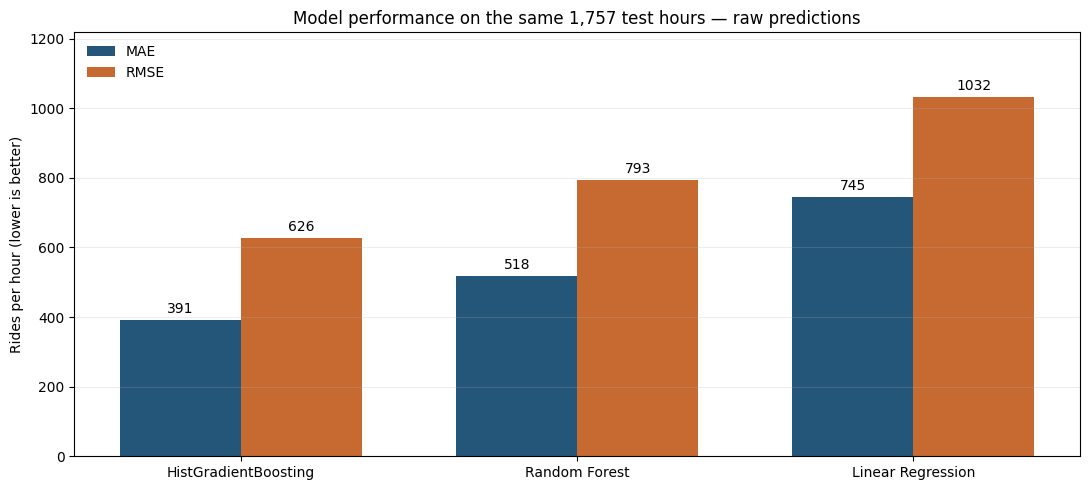

In [10]:
plot_models = comparison["Model"].tolist()
plot_positions = np.arange(len(plot_models))
bar_width = 0.36
fig, ax = plt.subplots(figsize=(11, 5))
mae_bars = ax.bar(plot_positions - bar_width / 2, comparison["MAE"], bar_width,
                  label="MAE", color="#24567A")
rmse_bars = ax.bar(plot_positions + bar_width / 2, comparison["RMSE"], bar_width,
                   label="RMSE", color="#C66A32")
ax.bar_label(mae_bars, fmt="%.0f", padding=3)
ax.bar_label(rmse_bars, fmt="%.0f", padding=3)
ax.set_xticks(plot_positions, plot_models)
ax.set_ylim(0, comparison["RMSE"].max() * 1.18)
ax.set_ylabel("Rides per hour (lower is better)")
ax.set_title("Model performance on the same 1,757 test hours — raw predictions")
ax.grid(axis="y", alpha=0.22)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 7. 连续七天的预测形状

**做什么：**沿用 04 的 2024-10-21 至 10-27，画出真实值与三个模型在连续 168 个测试小时的预测。**为什么：**整体指标可能掩盖早晚高峰、夜间低谷或周末模式的局部表现。**输入：**同一测试时段的原始预测。**输出：**七天时间序列图；灰色区表示周末。

图只能检查这一周的形状。模型优劣仍按全部 1,757 小时的表格判断。

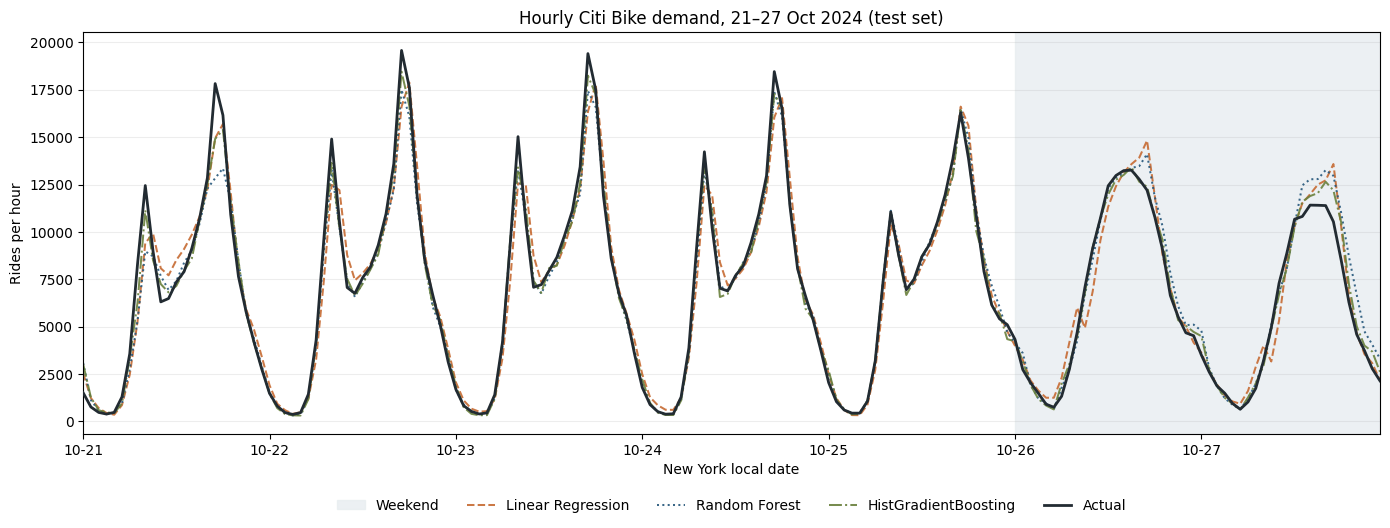

In [11]:
results = pd.DataFrame({"timestamp": test_time.to_numpy(), "Actual": y_test.to_numpy()})
for model_name, prediction in predictions.items():
    results[model_name] = prediction
results["hour"] = results["timestamp"].dt.hour
results["day_of_week"] = results["timestamp"].dt.dayofweek

week_start = pd.Timestamp("2024-10-21 00:00")
week_end = week_start + pd.Timedelta(days=7)
one_week = results.loc[
    results["timestamp"].ge(week_start) & results["timestamp"].lt(week_end)
].copy()
assert len(one_week) == 168
assert one_week["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()

fig, ax = plt.subplots(figsize=(14, 5.4))
ax.axvspan(pd.Timestamp("2024-10-26"), week_end, color="#E8EDF0", alpha=0.8,
           label="Weekend")
for model_name, style in [
    ("Linear Regression", "--"),
    ("Random Forest", ":"),
    ("HistGradientBoosting", "-."),
]:
    ax.plot(one_week["timestamp"], one_week[model_name],
            color=MODEL_COLORS[model_name], linestyle=style, linewidth=1.45,
            alpha=0.9, label=model_name)
ax.plot(one_week["timestamp"], one_week["Actual"], color="#222B32",
        linewidth=2.0, label="Actual", zorder=5)
ax.set(title="Hourly Citi Bike demand, 21–27 Oct 2024 (test set)",
       xlabel="New York local date", ylabel="Rides per hour")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.set_xlim(one_week["timestamp"].min(), one_week["timestamp"].max())
ax.grid(axis="y", alpha=0.22)
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.13))
fig.tight_layout()
plt.show()

### 7.1 用局部误差辅助读图

**做什么：**在同一周分别量化工作日早高峰、晚高峰、00–05 点夜间以及周末的 MAE 和平均误差。**为什么：**多条线重叠时，单靠目测很难判断谁更贴近真实值。**输入：**上图的 168 个小时。**输出：**局部模式诊断表；这里是读图辅助，不替代全测试集排名。

In [12]:
week_patterns = {
    "Weekday morning 07–09": (one_week["day_of_week"] < 5) & one_week["hour"].isin([7, 8, 9]),
    "Weekday evening 16–19": (one_week["day_of_week"] < 5) & one_week["hour"].isin([16, 17, 18, 19]),
    "Overnight 00–05": one_week["hour"].isin(range(6)),
    "Weekend all hours": one_week["day_of_week"] >= 5,
}
week_pattern_rows = []
for pattern, mask in week_patterns.items():
    subset = one_week.loc[mask]
    for model_name in models:
        error = subset["Actual"] - subset[model_name]
        week_pattern_rows.append({
            "Pattern": pattern, "Model": model_name, "Hours": len(subset),
            "Mean Error": error.mean(), "MAE": error.abs().mean(),
        })
week_pattern_table = pd.DataFrame(week_pattern_rows).set_index(["Pattern", "Model"])
display(week_pattern_table.round(1))
print("Mean Error = Actual − Prediction；正值表示平均低估，负值表示平均高估。")

Hours  Mean Error     MAE
Pattern               Model                                          
Weekday morning 07–09 Linear Regression        15       910.5  1822.3
                      Random Forest            15       760.0   988.9
                      HistGradientBoosting     15       436.9   678.8
Weekday evening 16–19 Linear Regression        20       347.9  1292.3
                      Random Forest            20       904.5  1187.3
                      HistGradientBoosting     20       510.6   704.7
Overnight 00–05       Linear Regression        42      -151.3   242.4
                      Random Forest            42       -77.0   183.7
                      HistGradientBoosting     42       -53.0   199.3
Weekend all hours     Linear Regression        48      -218.0   767.9
                      Random Forest            48      -538.1   726.1
                      HistGradientBoosting     48      -205.9   407.5

Mean Error = Actual − Prediction；正值表示平均低估，负值表示平均高估。


**本周观察：**工作日早晚两次需求高峰在曲线中都很明显；HistGradientBoosting 在这一周的工作日早高峰（MAE 678.8）与晚高峰（704.7）最接近实际值。夜间 00–05 点三个模型误差都较低，其中 Random Forest 的 MAE 183.7 略低于 HistGradientBoosting 的 199.3。周末的需求形状与工作日不同，HistGradientBoosting 的周末 MAE 407.5，低于另外两者。这些是单周观察，整体选择仍看第 6 节的全部测试小时。

## 8. 工作日通勤高峰

**做什么：**按 04 的定义，分别比较工作日 07–09 点和 16–19 点的平均误差与 MAE。**为什么：**整体 MAE 下降不保证高需求时段也改善。**输入：**整个测试集的真实值及原始预测。**输出：**每段每模型的样本数、Mean Error 与 MAE。

`Mean Error = Actual − Prediction`：正值代表平均低估，负值代表平均高估；MAE 不会让正负误差互相抵消。

In [13]:
weekday_results = results.loc[results["day_of_week"] < 5]
peak_periods = {
    "Morning 07–09": [7, 8, 9],
    "Evening 16–19": [16, 17, 18, 19],
}
peak_rows = []
for period, hours in peak_periods.items():
    peak = weekday_results.loc[weekday_results["hour"].isin(hours)]
    for model_name in models:
        error = peak["Actual"] - peak[model_name]
        peak_rows.append({
            "Period": period, "Model": model_name, "Hours": len(peak),
            "Mean Error": error.mean(), "MAE": error.abs().mean(),
        })
peak_comparison = pd.DataFrame(peak_rows).set_index(["Period", "Model"])
assert peak_comparison.loc[("Morning 07–09", "Linear Regression"), "Hours"] == 156
assert peak_comparison.loc[("Evening 16–19", "Linear Regression"), "Hours"] == 208
display(peak_comparison.round(1))

Hours  Mean Error     MAE
Period        Model                                          
Morning 07–09 Linear Regression       156      -272.2  1389.4
              Random Forest           156       124.7   780.4
              HistGradientBoosting    156         0.6   597.4
Evening 16–19 Linear Regression       208      -474.1  1074.0
              Random Forest           208      -100.5   996.4
              HistGradientBoosting    208      -141.8   776.4

## 9. Random Forest Feature Importance

**做什么：**读取森林自带的 `feature_importances_`，显示贡献最大的 15 个输入列。**为什么：**它可以帮助检查模型主要使用了哪些 lag、时间 dummy 和天气字段。**输入：**已训练森林及同一特征列名。**输出：**Top 15 表与横向排名图。

这是基于树分裂的不纯度重要性：相关特征可能互相分摊分数，连续变量也可能更容易得到较高分。它**不能证明因果关系**。`HistGradientBoostingRegressor` 没有在这里直接提供同名属性，因此不为它伪造重要性。

,Feature,Importance
0,lag_1,0.6385
1,lag_168,0.2285
2,lag_24,0.0925
3,temperature_2m,0.0069
4,relative_humidity_2m,0.0061
5,hour_8,0.0052
6,precipitation,0.0044
7,hour_7,0.0041
8,wind_speed_10m,0.0028
9,hour_19,0.0011


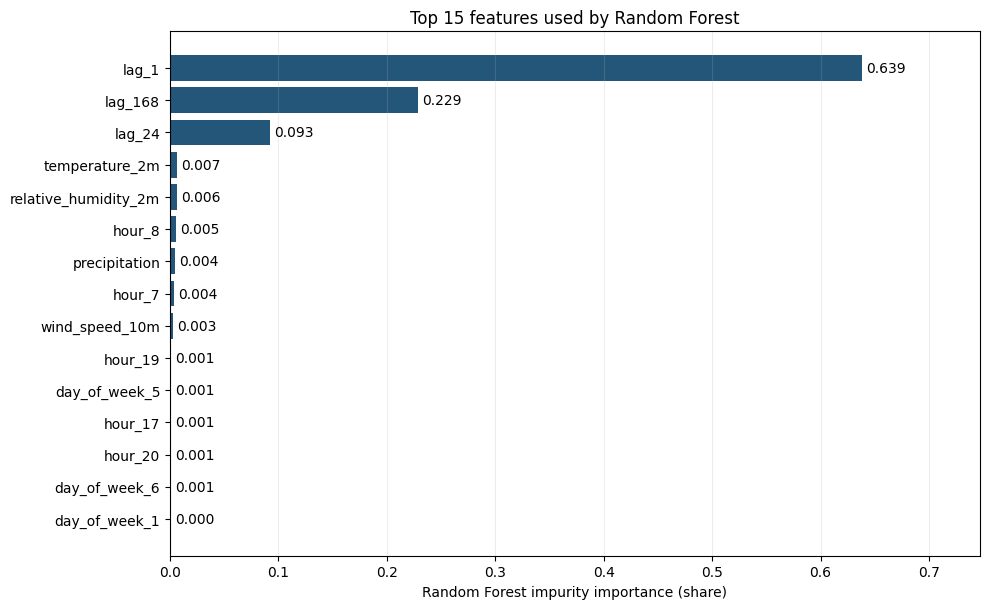

In [14]:
forest = models["Random Forest"]
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": forest.feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)
assert np.isclose(feature_importance["Importance"].sum(), 1.0)
top15 = feature_importance.head(15).copy()
display(top15.round({"Importance": 4}))

fig, ax = plt.subplots(figsize=(10, 6.2))
ranked = top15.iloc[::-1]
bars = ax.barh(ranked["Feature"], ranked["Importance"], color="#24567A")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlim(0, top15["Importance"].max() * 1.17)
ax.set_xlabel("Random Forest impurity importance (share)")
ax.set_title("Top 15 features used by Random Forest")
ax.grid(axis="x", alpha=0.22)
fig.tight_layout()
plt.show()

### 9.1 合并查看特征类别

**做什么：**把已有 45 列的重要性按 lag、hour、day_of_week、month、weather 汇总。**为什么：**One-Hot 时间变量分散在多列；类别总分可以补充 Top 15 单列排名。**输入：**森林已给出的 45 个重要性值。**输出：**类别汇总表；没有构造新的模型特征。

In [15]:
def feature_group(name):
    if name.startswith("lag_"):
        return "Lag demand"
    if name.startswith("hour_"):
        return "Hour one-hot"
    if name.startswith("day_of_week_"):
        return "Day-of-week one-hot"
    if name.startswith("month_"):
        return "Month one-hot"
    return "Weather"

importance_by_group = feature_importance.assign(
    Group=feature_importance["Feature"].map(feature_group)
).groupby("Group", as_index=False)["Importance"].sum().sort_values("Importance", ascending=False)
display(importance_by_group.round({"Importance": 4}))

,Group,Importance
2,Lag demand,0.9596
4,Weather,0.0201
1,Hour one-hot,0.0156
0,Day-of-week one-hot,0.0031
3,Month one-hot,0.0016


## 10. 训练／测试差距与过拟合检查

**做什么：**在同一训练集和测试集上算每个模型的 MAE，定义 `Generalization Gap = Test MAE − Train MAE`。**为什么：**树可以把训练误差压得很低，但我们关心的是未来时段误差。**输入：**已训练模型、固定矩阵和目标值。**输出：**同口径差距表。

较大的正差距是需要警惕的信号；它也可能受到 10–12 月季节变化影响，单次时间切分不能单独证明过拟合。判断模型好坏仍以相同测试集的结果为主。

In [16]:
gap_rows = []
for model_name, model in models.items():
    train_mae = mean_absolute_error(y_train, model.predict(X_train))
    test_mae = comparison_by_model.loc[model_name, "MAE"]
    gap_rows.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Generalization Gap": test_mae - train_mae,
    })
generalization_gap = pd.DataFrame(gap_rows).sort_values("Test MAE").reset_index(drop=True)
display(generalization_gap.round({
    "Train MAE": 2, "Test MAE": 2, "Generalization Gap": 2,
}))

,Model,Train MAE,Test MAE,Generalization Gap
0,HistGradientBoosting,246.16,391.42,145.27
1,Random Forest,245.42,518.16,272.74
2,Linear Regression,641.29,745.08,103.79


## 11. 预测值合理性与零下裁剪的影响

**做什么：**检查各模型原始预测的最小值、最大值、负数数量；再额外计算 `clip(prediction, 0, None)` 后的指标。**为什么：**需求不可能为负，但直接裁剪会改变模型输出及指标；必须保留原始比较结果。**输入：**同一测试集的原始预测。**输出：**范围表，以及明确标注 Raw／Clipped 的补充表。模型排名仍以第 6 节 Raw Prediction 为准。

In [17]:
sanity_rows = []
clipped_rows = []
for model_name, prediction in predictions.items():
    sanity_rows.append({
        "Model": model_name,
        "Min Prediction": np.min(prediction),
        "Max Prediction": np.max(prediction),
        "Negative Predictions": int((prediction < 0).sum()),
    })
    for variant, values in [
        ("Raw Prediction", prediction),
        ("Clipped Prediction", np.clip(prediction, 0, None)),
    ]:
        clipped_rows.append({
            "Model": model_name, "Variant": variant,
            "MAE": mean_absolute_error(y_test, values),
            "RMSE": np.sqrt(mean_squared_error(y_test, values)),
            "R²": r2_score(y_test, values),
        })
sanity_check = pd.DataFrame(sanity_rows)
clip_comparison = pd.DataFrame(clipped_rows)
display(sanity_check.round({"Min Prediction": 2, "Max Prediction": 2}))
display(clip_comparison.round({"MAE": 2, "RMSE": 2, "R²": 3}))

,Model,Min Prediction,Max Prediction,Negative Predictions
0,Linear Regression,-322.82,18257.87,28
1,Random Forest,129.87,18537.48,0
2,HistGradientBoosting,5.36,18597.25,0


,Model,Variant,MAE,RMSE,R²
0,Linear Regression,Raw Prediction,745.08,1031.98,0.930
1,Linear Regression,Clipped Prediction,743.45,1031.15,0.930
2,Random Forest,Raw Prediction,518.16,792.99,0.959
3,Random Forest,Clipped Prediction,518.16,792.99,0.959
4,HistGradientBoosting,Raw Prediction,391.42,626.17,0.974
5,HistGradientBoosting,Clipped Prediction,391.42,626.17,0.974


## 12. 实验总结

**做什么：**直接由本次执行的表格生成结论，避免手写结论与结果不一致。**输入：**全测试集指标、高峰误差、重要性和泛化差距。**输出：**模型选择、改善幅度、局限与下一步判断。

In [18]:
best_gap_row = generalization_gap.set_index("Model").loc[best_model_name]
forest_gap_row = generalization_gap.set_index("Model").loc["Random Forest"]
boost_gap_row = generalization_gap.set_index("Model").loc["HistGradientBoosting"]
morning_linear = peak_comparison.loc[("Morning 07–09", "Linear Regression"), "MAE"]
evening_linear = peak_comparison.loc[("Evening 16–19", "Linear Regression"), "MAE"]
morning_best = peak_comparison.loc[("Morning 07–09", best_model_name), "MAE"]
evening_best = peak_comparison.loc[("Evening 16–19", best_model_name), "MAE"]
peak_verdict = (
    f"早高峰 MAE {morning_linear:,.1f} → {morning_best:,.1f}；"
    f"晚高峰 {evening_linear:,.1f} → {evening_best:,.1f}。"
)
top_features = ", ".join(top15["Feature"].head(5))
forest_ratio = forest_gap_row["Test MAE"] / forest_gap_row["Train MAE"]
boost_ratio = boost_gap_row["Test MAE"] / boost_gap_row["Train MAE"]

summary_lines = [
    f"1. **最低测试 MAE：**{best_model_name}，MAE **{best_mae:,.2f}** 次/小时；其 RMSE **{comparison_by_model.loc[best_model_name, 'RMSE']:,.2f}**，R² **{comparison_by_model.loc[best_model_name, 'R²']:.3f}**。",
    f"2. **对比 V2-D Linear Regression：**基线 MAE {linear_mae:,.2f} → {best_mae:,.2f}，改善 **{linear_mae - best_mae:,.2f}** 次/小时（**{mae_improvement_pct:.2f}%**）。所有主指标使用未裁剪预测。",
    f"3. **过拟合检查：**Random Forest 的训练／测试 MAE 为 **{forest_gap_row['Train MAE']:,.2f} / {forest_gap_row['Test MAE']:,.2f}** （差距 {forest_gap_row['Generalization Gap']:,.2f}；{forest_ratio:.2f} 倍），存在明显泛化差距，是过拟合警讯。HistGradientBoosting 为 **{boost_gap_row['Train MAE']:,.2f} / {boost_gap_row['Test MAE']:,.2f}** （差距 {boost_gap_row['Generalization Gap']:,.2f}；{boost_ratio:.2f} 倍），也有差距但测试 MAE 最低。季节变化可能贡献一部分差距，单次切分不能单独证明纯粹过拟合。",
    f"4. **重要特征：**森林前五名为 `{top_features}`；完整 Top 15 和特征类别分数见第 9 节。它们只描述模型使用情况，不代表因果关系。",
    f"5. **通勤高峰：**相对线性基线，最佳模型的{peak_verdict}平均偏差方向见第 8 节。",
    "6. **树模型的取舍：**它们能自动学习阈值和非线性交互，通常无需标准化；代价是更难像线性系数那样解释，计算成本更高，也可能拟合训练期噪声。以相同测试集误差决定本次选择。",
    "7. **下一步：**值得在独立实验中研究 Rolling Features，但应保持同一时间验证口径，并只使用预测时刻以前的数据。本 Notebook 未加入 rolling，也未创建 06。",
]
display(Markdown((chr(10) * 2).join(summary_lines)))

1. **最低测试 MAE：**HistGradientBoosting，MAE **391.42** 次/小时；其 RMSE **626.17**，R² **0.974**。

2. **对比 V2-D Linear Regression：**基线 MAE 745.08 → 391.42，改善 **353.65** 次/小时（**47.47%**）。所有主指标使用未裁剪预测。

3. **过拟合检查：**Random Forest 的训练／测试 MAE 为 **245.42 / 518.16** （差距 272.74；2.11 倍），存在明显泛化差距，是过拟合警讯。HistGradientBoosting 为 **246.16 / 391.42** （差距 145.27；1.59 倍），也有差距但测试 MAE 最低。季节变化可能贡献一部分差距，单次切分不能单独证明纯粹过拟合。

4. **重要特征：**森林前五名为 `lag_1, lag_168, lag_24, temperature_2m, relative_humidity_2m`；完整 Top 15 和特征类别分数见第 9 节。它们只描述模型使用情况，不代表因果关系。

5. **通勤高峰：**相对线性基线，最佳模型的早高峰 MAE 1,389.4 → 597.4；晚高峰 1,074.0 → 776.4。平均偏差方向见第 8 节。

6. **树模型的取舍：**它们能自动学习阈值和非线性交互，通常无需标准化；代价是更难像线性系数那样解释，计算成本更高，也可能拟合训练期噪声。以相同测试集误差决定本次选择。

7. **下一步：**值得在独立实验中研究 Rolling Features，但应保持同一时间验证口径，并只使用预测时刻以前的数据。本 Notebook 未加入 rolling，也未创建 06。